<a href="https://colab.research.google.com/github/2024tm93554/aceest-fitness-gym/blob/main/mypro_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd

df = pd.read_excel("DailyProductivity_BehaviourTracker.xlsx")

df.head()

,Timestamp,Name,Date,Screen_Time,Social_Media_Time,Work/Study_Hours,Sleep_Hours,Sleep_Quality,Steps,Caffeine(cups),Commute_Time(hrs),Day_of_Week,Productive,Gender
0,2026-04-26 19:47:02,Jason Immaanuel,2026-04-26,1,0.3,0.3,6,5,2500,1,0.2,Sunday,Yes,Male
1,2026-04-26 19:49:03,Vinothkumar,2026-04-26,2,1,8,7,4,10000,1,2026-02-01 00:00:00,Sunday,Yes,Male
2,2026-04-26 19:50:32,Davina,2026-04-26,2hrs,1.5 hrs,3hrs,8+hrs,4,500,1 cup,2 min,Sunday,Yes,Female
3,2026-04-26 19:50:37,Ishanvi,2026-04-26,12 - 15hrs,2hrs,-,5-6 hrs,3,1500,-,Work from home,Sunday,NaN,Female
4,2026-04-26 19:54:32,Aliza,2026-04-26,2 hours,2 hours,10 hours,6 hours,4,NaN,2,2 hours 30 mins,Sunday,Yes,Female


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           201 non-null    datetime64[ns]
 1   Name                199 non-null    object        
 2   Date                200 non-null    datetime64[ns]
 3   Screen_Time         201 non-null    object        
 4   Social_Media_Time   198 non-null    object        
 5   Work/Study_Hours    198 non-null    object        
 6   Sleep_Hours         197 non-null    object        
 7   Sleep_Quality       201 non-null    int64         
 8   Steps               178 non-null    object        
 9   Caffeine(cups)      180 non-null    object        
 10  Commute_Time(hrs)   178 non-null    object        
 11  Day_of_Week         199 non-null    object        
 12  Productive          195 non-null    object        
 13  Gender              201 non-null    object        

In [35]:
df.describe()

,Timestamp,Date,Sleep_Quality
count,201,200,201.000000
mean,2026-04-28 12:02:28.303482368,2026-04-28 04:49:25.500000,3.681592
min,2026-04-26 19:47:02,2026-04-24 00:00:00,2.000000
25%,2026-04-27 00:00:00,2026-04-27 00:00:00,3.000000
50%,2026-04-27 10:49:12,2026-04-27 00:00:00,4.000000
75%,2026-04-29 00:00:00,2026-04-29 00:00:00,4.000000
max,2026-05-05 11:27:19,2026-05-05 11:26:07,8.000000
std,NaN,NaN,0.958180


In [36]:
df.isnull().sum()

,0
Timestamp,0
Name,2
Date,1
Screen_Time,0
Social_Media_Time,3
Work/Study_Hours,3
Sleep_Hours,4
Sleep_Quality,0
Steps,23
Caffeine(cups),21


In [6]:
df.dropna(inplace=True)

In [37]:
df["Screen_Time"] = (
    df["Screen_Time"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

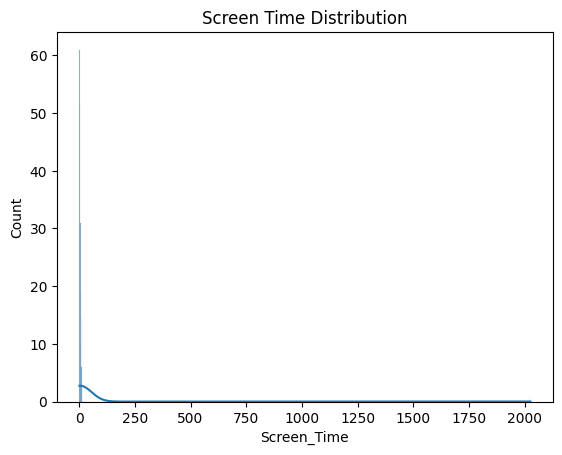

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Screen_Time"], kde=True)

plt.title("Screen Time Distribution")

plt.show()

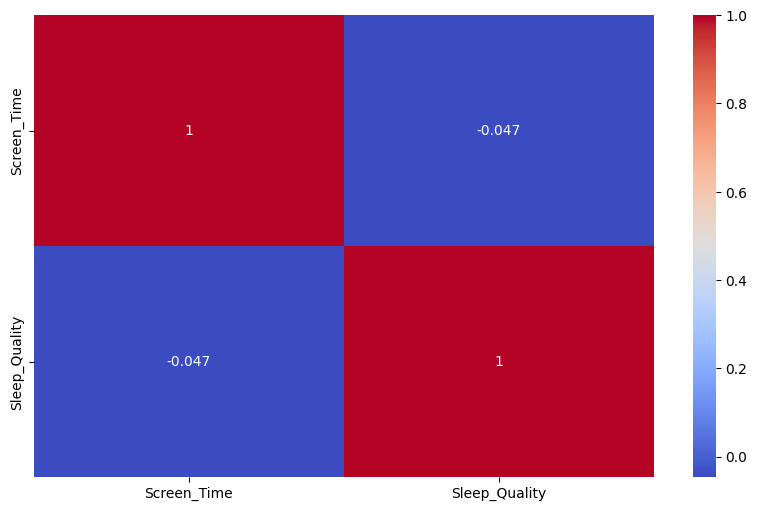

In [39]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [40]:
print(df.columns)

Index(['Timestamp', 'Name', 'Date', 'Screen_Time', 'Social_Media_Time ',
       'Work/Study_Hours', 'Sleep_Hours', 'Sleep_Quality', 'Steps',
       'Caffeine(cups)', 'Commute_Time(hrs)', 'Day_of_Week', 'Productive',
       'Gender'],
      dtype='object')


In [43]:
df["Social_Media_Time "] = (
    df["Social_Media_Time "]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

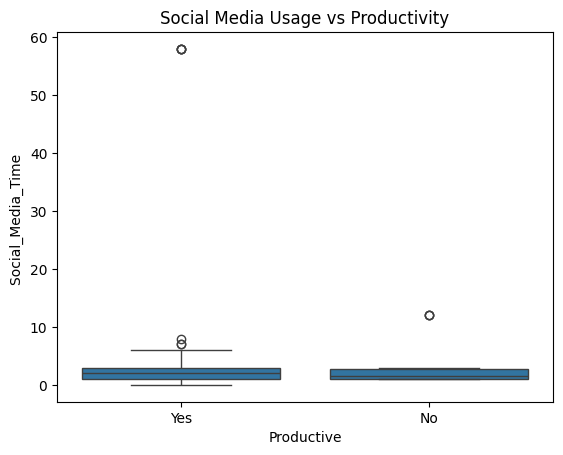

In [44]:
sns.boxplot(
    x="Productive",
    y="Social_Media_Time ",
    data=df
)

plt.title("Social Media Usage vs Productivity")

plt.show()

In [48]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# Columns containing numeric text
columns_to_clean = [
    "screen_time",
    "social_media_time",
    "sleep_hours",
    "work_study_hours",
    "caffeine_intake",
    "exercise_time"
]

# Convert text values like '3hrs' -> 3.0
for col in columns_to_clean:

    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
        )

print(df.dtypes)

timestamp            datetime64[ns]
name                         object
date                 datetime64[ns]
screen_time                 float64
social_media_time           float64
work_study_hours            float64
sleep_hours                 float64
sleep_quality                 int64
steps                        object
caffeine(cups)               object
commute_time(hrs)            object
day_of_week                  object
productive                   object
gender                       object
dtype: object


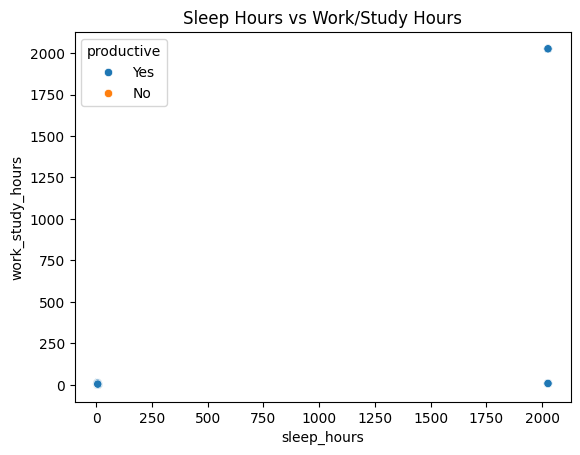

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="sleep_hours",
    y="work_study_hours",
    hue="productive",
    data=df
)

plt.title("Sleep Hours vs Work/Study Hours")

plt.show()

In [52]:
print(df.columns)

Index(['timestamp', 'name', 'date', 'screen_time', 'social_media_time',
       'work_study_hours', 'sleep_hours', 'sleep_quality', 'steps',
       'caffeine(cups)', 'commute_time(hrs)', 'day_of_week', 'productive',
       'gender'],
      dtype='object')


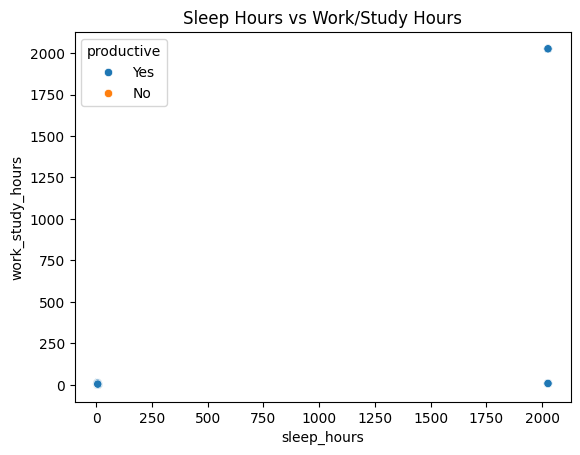

In [53]:
sns.scatterplot(
    x="sleep_hours",
    y="work_study_hours",
    hue="productive",
    data=df
)

plt.title("Sleep Hours vs Work/Study Hours")

plt.show()

In [55]:
print(df.columns.tolist())

['timestamp', 'name', 'date', 'screen_time', 'social_media_time', 'work_study_hours', 'sleep_hours', 'sleep_quality', 'steps', 'caffeine(cups)', 'commute_time(hrs)', 'day_of_week', 'productive', 'gender']


In [56]:
import pandas as pd
import numpy as np

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# Columns to clean
columns_to_clean = [
    "screen_time",
    "social_media_time",
    "sleep_hours",
    "work_study_hours",
    "caffeine_intake"
]

# Convert text values to numeric
for col in columns_to_clean:

    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
        )

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          201 non-null    datetime64[ns]
 1   name               199 non-null    object        
 2   date               200 non-null    datetime64[ns]
 3   screen_time        201 non-null    float64       
 4   social_media_time  198 non-null    float64       
 5   work_study_hours   195 non-null    float64       
 6   sleep_hours        197 non-null    float64       
 7   sleep_quality      201 non-null    int64         
 8   steps              178 non-null    object        
 9   caffeine(cups)     180 non-null    object        
 10  commute_time(hrs)  178 non-null    object        
 11  day_of_week        199 non-null    object        
 12  productive         195 non-null    object        
 13  gender             201 non-null    object        
dtypes: datetim

In [63]:
df["sleep_hours"] = (
    df["sleep_hours"]
    .astype(str)
    .str.replace("hrs", "", regex=False)
    .astype(float)
)

df["work_study_hours"] = (
    df["work_study_hours"]
    .astype(str)
    .str.replace("hrs", "", regex=False)
    .astype(float)
)

In [7]:
import pandas as pd

In [8]:
df = pd.read_excel("DailyProductivity_BehaviourTracker.xlsx")

In [9]:
df.head()

,Timestamp,Name,Date,Screen_Time,Social_Media_Time,Work/Study_Hours,Sleep_Hours,Sleep_Quality,Steps,Caffeine(cups),Commute_Time(hrs),Day_of_Week,Productive,Gender
0,2026-04-26 19:47:02,Jason Immaanuel,2026-04-26,1,0.3,0.3,6,5,2500,1,0.2,Sunday,Yes,Male
1,2026-04-26 19:49:03,Vinothkumar,2026-04-26,2,1,8,7,4,10000,1,2026-02-01 00:00:00,Sunday,Yes,Male
2,2026-04-26 19:50:32,Davina,2026-04-26,2hrs,1.5 hrs,3hrs,8+hrs,4,500,1 cup,2 min,Sunday,Yes,Female
3,2026-04-26 19:50:37,Ishanvi,2026-04-26,12 - 15hrs,2hrs,-,5-6 hrs,3,1500,-,Work from home,Sunday,NaN,Female
4,2026-04-26 19:54:32,Aliza,2026-04-26,2 hours,2 hours,10 hours,6 hours,4,NaN,2,2 hours 30 mins,Sunday,Yes,Female


In [11]:
print(df.columns)

Index(['Timestamp', 'Name', 'Date', 'Screen_Time', 'Social_Media_Time ',
       'Work/Study_Hours', 'Sleep_Hours', 'Sleep_Quality', 'Steps',
       'Caffeine(cups)', 'Commute_Time(hrs)', 'Day_of_Week', 'Productive',
       'Gender'],
      dtype='object')


In [12]:
import re

def clean_numeric(value):

    value = str(value)

    match = re.search(r"\d+(\.\d+)?", value)

    if match:
        return float(match.group())

    return None


df["Sleep_Hours"] = (
    df["Sleep_Hours"]
    .apply(clean_numeric)
)

df["Work/Study_Hours"] = (
    df["Work/Study_Hours"]
    .apply(clean_numeric)
)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("DailyProductivity_BehaviourTracker.xlsx")

# Show first rows
print(df.head())

# Show columns
print(df.columns)

            Timestamp             Name       Date Screen_Time  \
0 2026-04-26 19:47:02  Jason Immaanuel 2026-04-26           1   
1 2026-04-26 19:49:03      Vinothkumar 2026-04-26           2   
2 2026-04-26 19:50:32           Davina 2026-04-26        2hrs   
3 2026-04-26 19:50:37          Ishanvi 2026-04-26  12 - 15hrs   
4 2026-04-26 19:54:32            Aliza 2026-04-26     2 hours   

  Social_Media_Time  Work/Study_Hours Sleep_Hours  Sleep_Quality  Steps  \
0                0.3              0.3           6              5   2500   
1                  1                8           7              4  10000   
2            1.5 hrs             3hrs       8+hrs              4    500   
3               2hrs                -     5-6 hrs              3   1500   
4            2 hours         10 hours     6 hours              4    NaN   

  Caffeine(cups)    Commute_Time(hrs) Day_of_Week Productive  Gender  
0              1                  0.2      Sunday        Yes    Male  
1              1

In [16]:
import re

def clean_numeric(value):

    value = str(value)

    match = re.search(r"\d+(\.\d+)?", value)

    if match:
        return float(match.group())

    return None


df["Sleep_Hours"] = (
    df["Sleep_Hours"]
    .apply(clean_numeric)
)

df["Work/Study_Hours"] = (
    df["Work/Study_Hours"]
    .apply(clean_numeric)
)

In [17]:
df[["Sleep_Hours", "Work/Study_Hours"]].head()

,Sleep_Hours,Work/Study_Hours
0,6.0,0.3
1,7.0,8.0
2,8.0,3.0
3,5.0,NaN
4,6.0,10.0


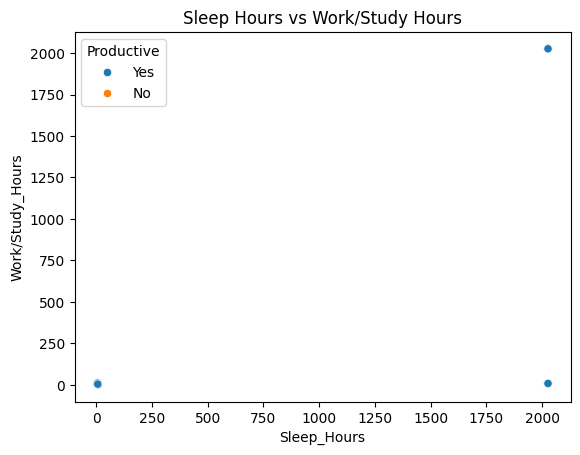

In [18]:
sns.scatterplot(
    x="Sleep_Hours",
    y="Work/Study_Hours",
    hue="Productive",
    data=df
)

plt.title("Sleep Hours vs Work/Study Hours")

plt.show()

In [20]:
columns_to_clean = [
    "Screen_Time",
    "Social_Media_Time ",
    "Work/Study_Hours",
    "Sleep_Hours",
    "Steps",
    "Caffeine(cups)",
    "Commute_Time(hrs)"
]

for col in columns_to_clean:
    df[col] = df[col].apply(clean_numeric)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 0 to 200
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Timestamp                       146 non-null    datetime64[ns]
 1   Name                            146 non-null    object        
 2   Date                            146 non-null    datetime64[ns]
 3   Screen Time (hrs) - approx      146 non-null    float64       
 4   Social Media Time (hrs)-approx  146 non-null    float64       
 5   Work/Study Hours                146 non-null    float64       
 6   Sleep Hours                     146 non-null    float64       
 7   Sleep Quality                   146 non-null    int64         
 8   Steps                           144 non-null    float64       
 9   Caffeine (cups)                 137 non-null    float64       
 10  Commute Time (hrs)              146 non-null    float64       
 11  Day of Week

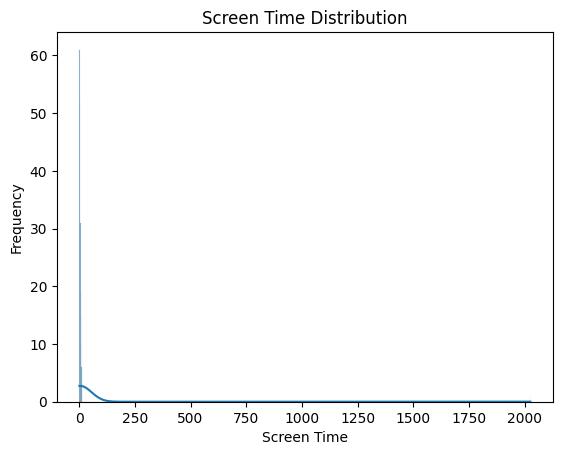

In [22]:
sns.histplot(
    df["Screen_Time"],
    kde=True
)
plt.savefig("graph1.png")
plt.title("Screen Time Distribution")

plt.xlabel("Screen Time")

plt.ylabel("Frequency")

plt.show()

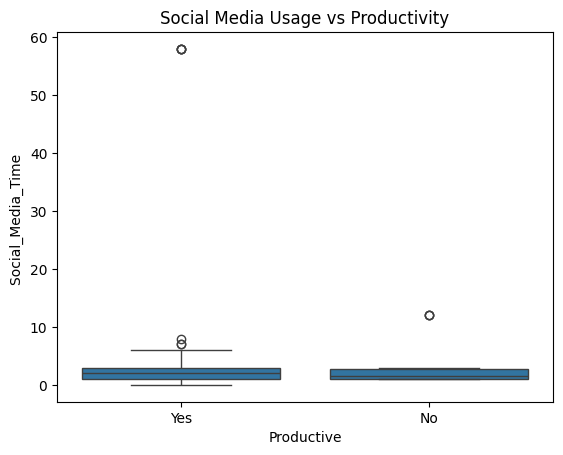

In [23]:
sns.boxplot(
    x="Productive",
    y="Social_Media_Time ",
    data=df
)

plt.title("Social Media Usage vs Productivity")

plt.show()

In [24]:
numeric_df = df.select_dtypes(include=['number'])

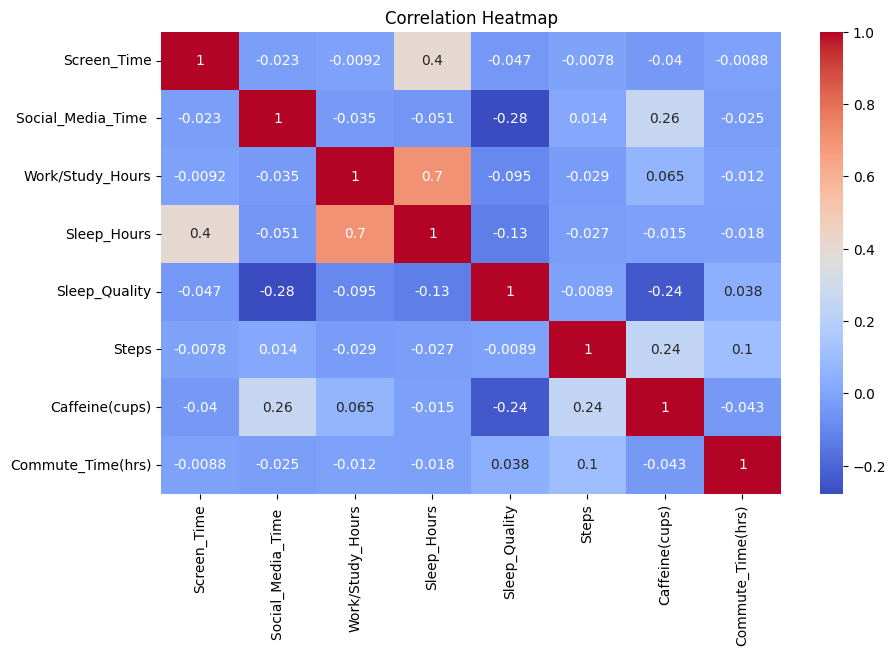

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

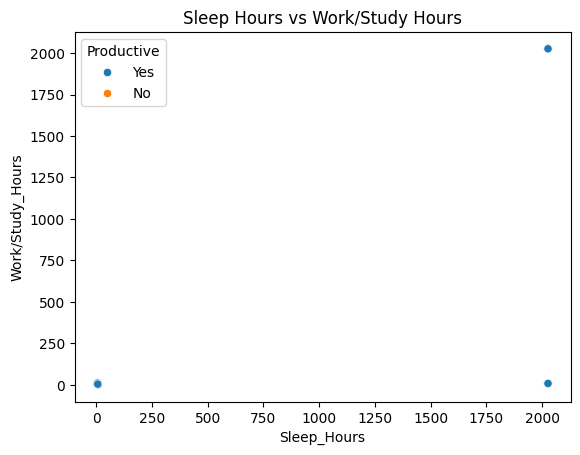

In [26]:
sns.scatterplot(
    x="Sleep_Hours",
    y="Work/Study_Hours",
    hue="Productive",
    data=df
)

plt.title("Sleep Hours vs Work/Study Hours")

plt.show()

In [27]:
import re

def clean_numeric(value):

    value = str(value)

    match = re.search(r"\d+(\.\d+)?", value)

    if match:
        return float(match.group())

    return None

In [28]:
columns_to_clean = [
    "Screen_Time",
    "Social_Media_Time ",
    "Work/Study_Hours",
    "Sleep_Hours",
    "Steps",
    "Caffeine(cups)",
    "Commute_Time(hrs)"
]

for col in columns_to_clean:
    df[col] = df[col].apply(clean_numeric)

In [29]:
df.isnull().sum()

,0
Timestamp,0
Name,2
Date,1
Screen_Time,0
Social_Media_Time,3
Work/Study_Hours,6
Sleep_Hours,4
Sleep_Quality,0
Steps,25
Caffeine(cups),43


In [30]:
df.dropna(inplace=True)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

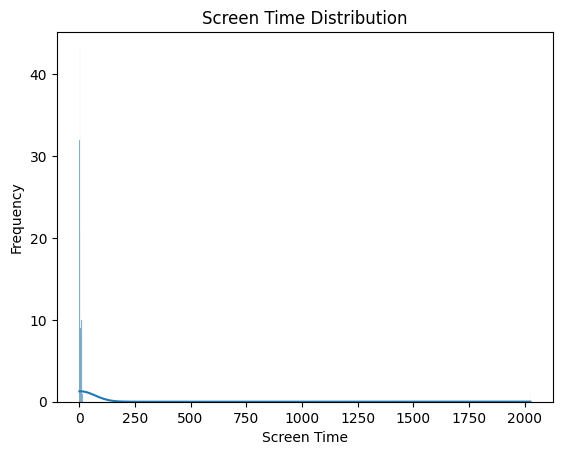

In [32]:
sns.histplot(
    df["Screen_Time"],
    kde=True
)

plt.title("Screen Time Distribution")

plt.xlabel("Screen Time")

plt.ylabel("Frequency")

plt.show()

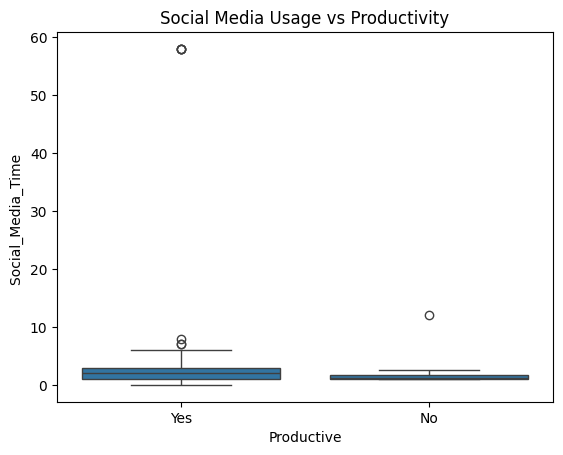

In [33]:
sns.boxplot(
    x="Productive",
    y="Social_Media_Time ",
    data=df
)

plt.title("Social Media Usage vs Productivity")

plt.show()

In [34]:
numeric_df = df.select_dtypes(include=['number'])

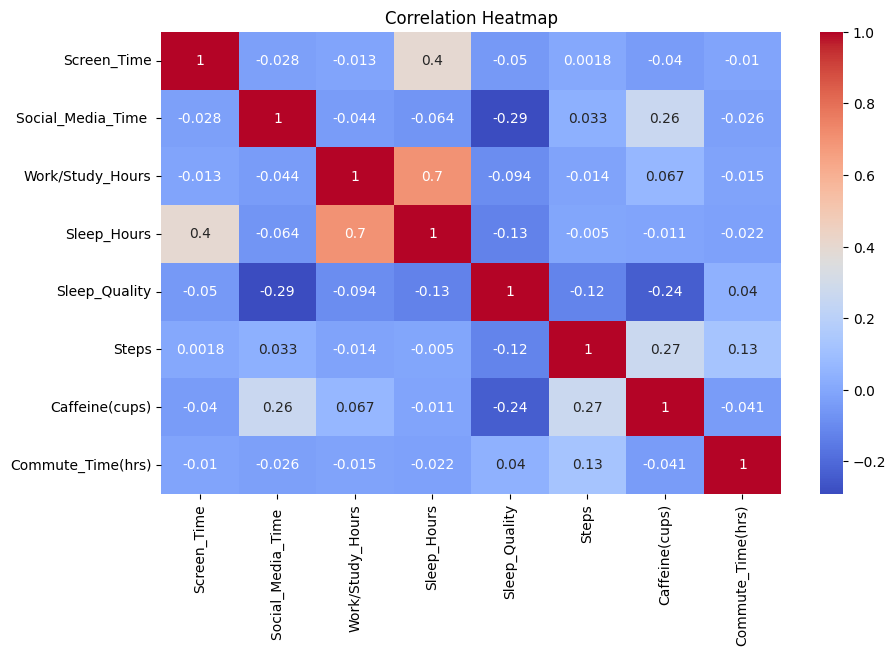

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

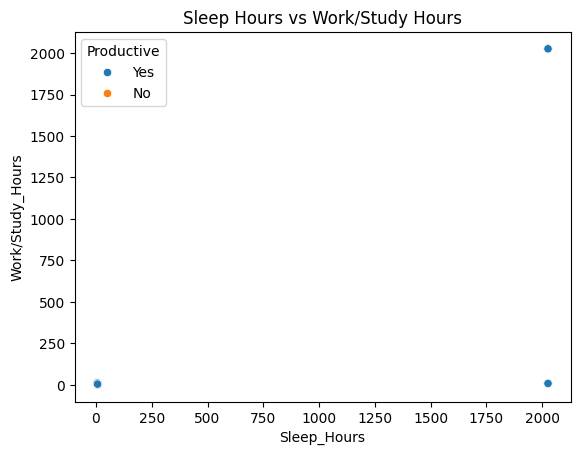

In [36]:
sns.scatterplot(
    x="Sleep_Hours",
    y="Work/Study_Hours",
    hue="Productive",
    data=df
)

plt.title("Sleep Hours vs Work/Study Hours")

plt.show()

In [37]:
df["Deep_Work_Ratio"] = (
    df["Work/Study_Hours"] /
    df["Screen_Time"]
)

In [38]:
df["Distraction_Score"] = (
    df["Social_Media_Time "] /
    df["Screen_Time"]
)

In [40]:
df_ml = df.drop(columns=[
    "Timestamp",
    "Name",
    "Date",
    "Day_of_Week"
])

In [41]:
df_ml["Gender"] = df_ml["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [42]:
X = df_ml.drop(columns=["Productive"])

y = df_ml["Productive"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
df["Deep_Work_Ratio"] = (
    df["Work/Study_Hours"] /
    df["Screen_Time"]
)
df["Distraction_Score"] = (
    df["Social_Media_Time "] /
    df["Screen_Time"]
)
df_ml = df.drop(columns=[
    "Timestamp",
    "Name",
    "Date",
    "Day_of_Week"
])
df_ml["Gender"] = df_ml["Gender"].map({
    "Male": 0,
    "Female": 1
})
X = df_ml.drop(columns=["Productive"])

y = df_ml["Productive"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(y_test, y_pred_lr)
)

0.9259259259259259


In [48]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(
    accuracy_score(y_test, y_pred_dt)
)

0.9259259259259259


In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [52]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf, pos_label='Yes')
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf, pos_label='Yes')
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf, pos_label='Yes')
)

Accuracy: 0.9629629629629629
Precision: 0.9615384615384616
Recall: 1.0
F1 Score: 0.9803921568627451
